# Phase 3: Optimized GPU with Sigmoid + BCE Loss (Kaggle Version)
**CSC14120 - Parallel Programming**

---

## Cải tiến so với Phase 3 gốc (MSE Loss)

### Thay đổi Architecture:
- **Output Activation:** Thêm Sigmoid sau Conv5 cuối cùng
- **Loss Function:** Binary Cross-Entropy (BCE) thay vì MSE

### Lý do sử dụng Sigmoid + BCE:

| Aspect | MSE (Phase 3 gốc) | BCE + Sigmoid (Version này) |
|:-------|:------------------|:----------------------------|
| Output range | Unbounded (-∞, +∞) | Bounded [0, 1] |
| Gradient behavior | Linear | Stronger near 0.5, weaker near 0/1 |
| Pixel validity | May need clipping | Always valid |
| Theory | Regression | Probabilistic reconstruction |

### BCE Loss Formula:
```
BCE = -[y*log(ŷ + ε) + (1-y)*log(1-ŷ + ε)] / N

where:
  y = target pixel value (normalized to [0,1])
  ŷ = sigmoid(model_output)
  ε = 1e-7 (numerical stability)
  N = total number of pixels
```

### Sigmoid Activation:
```
sigmoid(x) = 1 / (1 + exp(-x))

Numerically stable version:
  if x >= 0: sigmoid(x) = 1 / (1 + exp(-x))
  if x < 0:  sigmoid(x) = exp(x) / (1 + exp(x))
```

---

## Hướng dẫn chạy trên Kaggle:
1. Upload project lên Kaggle Dataset
2. Tạo notebook mới và add dataset
3. Chạy tất cả cells

In [1]:
# Kiểm tra GPU
!nvidia-smi
!nvcc --version

Wed Dec 24 04:59:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Copy project từ Kaggle dataset
import os
import glob
import shutil
import time

import random
import numpy as np
import cupy as cp

random.seed(42)
np.random.seed(42)
cp.random.seed(42)

import os
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

input_dir = '/kaggle/input'
src_dirs = glob.glob(f'{input_dir}/**/src', recursive=True)

if src_dirs:
    project_dir = os.path.dirname(src_dirs[0])
    print(f"Found project at: {project_dir}")
    shutil.copytree(project_dir, '/kaggle/working/project', dirs_exist_ok=True)
    
    for root, dirs, _ in os.walk('/kaggle/working/project'):
        if 'src' in dirs:
            os.chdir(root)
            break
else:
    print("ERROR: Project not found")

print(f"Working directory: {os.getcwd()}")
!ls

Found project at: /kaggle/input/phase3-v98
Working directory: /kaggle/working/project
include  src


In [3]:
# Download CIFAR-10
import urllib.request
import tarfile

os.makedirs('data', exist_ok=True)

if not os.path.exists('data/data_batch_1.bin'):
    print('Downloading CIFAR-10...')
    urllib.request.urlretrieve(
        'https://www.cs.toronto.edu/~kriz/cifar-10-binary.tar.gz', 
        'data/cifar.tar.gz'
    )
    with tarfile.open('data/cifar.tar.gz', 'r:gz') as tar:
        tar.extractall('data')
    !mv data/cifar-10-batches-bin/* data/

print('CIFAR-10 ready!')

CIFAR-10 ready!


## Optimize

## Build Phase 3 với BCE Loss

**Compiler flags:**
- `-O3`: Maximum optimization
- `-DUSE_OPTIMIZED_KERNELS`: Enable cuDNN path
- `--use_fast_math`: Fast math operations
- `-lcublas -lcudnn`: Link cuBLAS and cuDNN

**Runtime flag:**
- `--bce-loss`: Enable BCE loss with Sigmoid output

In [4]:
# Build Phase 3 with cuDNN (BCE is runtime flag)
# Note: Kaggle uses sm_70 for Tesla P100 or sm_75 for Tesla T4
!nvcc -O3 -arch=sm_75 -DUSE_OPTIMIZED_KERNELS \
    -Iinclude -lcublas -lcudnn -lcurand \
    -o gpu_train_bce \
    src/main_gpu.cu src/layers_gpu.cu src/gpu_autoencoder.cu src/layers_gpu_opt.cu src/dataset.cpp

print('Build completed')

Build completed


## Training với BCE Loss

**Lưu ý quan trọng:**
- BCE loss values thường **cao hơn** MSE loss (khác scale)
- Không so sánh trực tiếp BCE loss với MSE loss
- Đánh giá qua reconstruction quality và downstream accuracy

In [5]:
!./gpu_train_bce --data data --epochs 20 --batch 64 --lr 0.001 \
    --bce-loss \
    --log phase3_bce.csv --log-txt phase3_bce.txt --save-weights phase3_bce.weights

# !nvprof --print-gpu-summary ./gpu_train_bce --data data --epochs 1 --batch 64 --lr 0.001 --bce-loss

=== GPU Autoencoder Training ===
GPU 0: Tesla T4 (SM 7.5, 15095 MB, 40 SMs)
GPU 1: Tesla T4 (SM 7.5, 15095 MB, 40 SMs)
Using GPU 0
Loading CIFAR-10 from: data
  Train: 50000, Test: 10000
  Batch: 64, Batches/epoch: 781
Initializing autoencoder...
Loss: BCE+Sigmoid

=== Training ===
Epochs: 20, LR: 0.001

  Epoch 1/20 | Batch 781/781 | Loss: 0.4753 | 41.1 ms
  Epoch 1: Avg=0.4877, 32.7s [BEST]
  Epoch 2/20 | Batch 781/781 | Loss: 0.4543 | 43.2 ms
  Epoch 2: Avg=0.4763, 32.6s [BEST]
  Epoch 3/20 | Batch 781/781 | Loss: 0.4653 | 42.2 ms
  Epoch 3: Avg=0.4732, 33.4s [BEST]
  Epoch 4/20 | Batch 781/781 | Loss: 0.4785 | 42.3 ms
  Epoch 4: Avg=0.4718, 32.8s [BEST]
  Epoch 5/20 | Batch 781/781 | Loss: 0.4805 | 42.2 ms
  Epoch 5: Avg=0.4708, 32.8s [BEST]
  Epoch 6/20 | Batch 781/781 | Loss: 0.4688 | 41.3 ms
  Epoch 6: Avg=0.4705, 33.0s [BEST]
  Epoch 7/20 | Batch 781/781 | Loss: 0.4792 | 41.5 ms
  Epoch 7: Avg=0.4698, 32.8s [BEST]
  Epoch 8/20 | Batch 781/781 | Loss: 0.4578 | 42.0 ms
  Epoch 8:

## Kết quả và Visualization

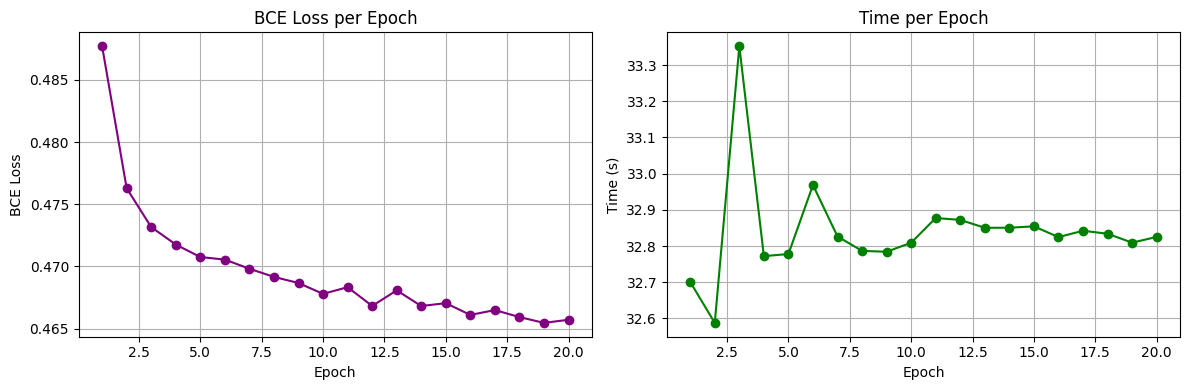

PHASE 3 BCE LOSS RESULTS (Kaggle)
Best BCE Loss: 0.465460
Final BCE Loss: 0.465712
Avg Time per Epoch: 32.84s
Total Training Time: 656.81s (10.95 min)


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('phase3_bce.csv')
ep = df[df['batch'].isna()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep['epoch'], ep['loss'], 'purple', marker='o')
ax1.set_title('BCE Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.grid(True)

ax2.plot(ep['epoch'], ep['epoch_time_sec'], 'green', marker='o')
ax2.set_title('Time per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Time (s)')
ax2.grid(True)

plt.tight_layout()
plt.savefig('phase3_bce_results.png', dpi=150)
plt.show()

print("="*50)
print("PHASE 3 BCE LOSS RESULTS (Kaggle)")
print("="*50)
print(f"Best BCE Loss: {ep['best_loss'].iloc[-1]:.6f}")
print(f"Final BCE Loss: {ep['loss'].iloc[-1]:.6f}")
print(f"Avg Time per Epoch: {ep['epoch_time_sec'].mean():.2f}s")
print(f"Total Training Time: {ep['epoch_time_sec'].sum():.2f}s ({ep['epoch_time_sec'].sum()/60:.2f} min)")
print("="*50)

In [7]:
# Show training log
print("="*60)
print("TRAINING LOG (last 30 lines)")
print("="*60)
!tail -30 phase3_bce.txt

TRAINING LOG (last 30 lines)
[2025-12-24 05:09:41]   Batch 500/781 | Loss: 0.475683 | 42.30 ms
[2025-12-24 05:09:43]   Batch 550/781 | Loss: 0.458772 | 42.11 ms
[2025-12-24 05:09:45]   Batch 600/781 | Loss: 0.469883 | 41.13 ms
[2025-12-24 05:09:47]   Batch 650/781 | Loss: 0.455552 | 42.21 ms
[2025-12-24 05:09:49]   Batch 700/781 | Loss: 0.479996 | 42.56 ms
[2025-12-24 05:09:51]   Batch 750/781 | Loss: 0.464247 | 42.69 ms
[2025-12-24 05:09:53]   Batch 781/781 | Loss: 0.460635 | 42.18 ms
[2025-12-24 05:09:53] Epoch 19/20 done: Loss=0.465460, Time=32.81s [BEST]
[2025-12-24 05:09:53] Best: 0.465460
[2025-12-24 05:09:53] --- Epoch 20/20 ---
[2025-12-24 05:09:55]   Batch 50/781 | Loss: 0.471268 | 41.50 ms
[2025-12-24 05:09:57]   Batch 100/781 | Loss: 0.463120 | 41.77 ms
[2025-12-24 05:09:59]   Batch 150/781 | Loss: 0.469545 | 42.18 ms
[2025-12-24 05:10:01]   Batch 200/781 | Loss: 0.461874 | 41.53 ms
[2025-12-24 05:10:03]   Batch 250/781 | Loss: 0.458896 | 42.17 ms
[2025-12-24 05:10:05]   Bat

In [8]:
import struct

path = "/kaggle/working/project/phase3_bce.weights"

with open(path, "rb") as f:
    # đọc header
    header = f.read(12)
    magic, version, num_layers = struct.unpack("III", header)
    print(f"MAGIC = {hex(magic)}, version = {version}, num_layers = {num_layers}")

    layers = []
    for li in range(num_layers):
        # in_c, out_c, k
        in_c, out_c, k = struct.unpack("iii", f.read(12))
        print(f"\nLayer {li}: in_c={in_c}, out_c={out_c}, k={k}")

        # weights
        (w_size,) = struct.unpack("i", f.read(4))
        w_bytes = f.read(4 * w_size)
        w = np.frombuffer(w_bytes, dtype=np.float32)
        print(f"  weights: shape=({out_c}, {in_c}, {k}, {k}), w_size={w_size}")
        print("  first 5 weights:", w[:5])

        # biases
        (b_size,) = struct.unpack("i", f.read(4))
        b_bytes = f.read(4 * b_size)
        b = np.frombuffer(b_bytes, dtype=np.float32)
        print(f"  bias: shape=({b_size},)")
        print("  first 5 biases:", b[:5])

        layers.append(((in_c, out_c, k), w, b))

MAGIC = 0x48414557, version = 2, num_layers = 5

Layer 0: in_c=3, out_c=256, k=3
  weights: shape=(256, 3, 3, 3), w_size=6912
  first 5 weights: [-0.03166181  0.28950244  0.28401554 -0.22205703  0.49845427]
  bias: shape=(256,)
  first 5 biases: [ 0.00015263 -0.00037414  0.00033628  0.00026695  0.00014836]

Layer 1: in_c=256, out_c=128, k=3
  weights: shape=(128, 256, 3, 3), w_size=294912
  first 5 weights: [-0.03847331 -0.0496867  -0.04080894 -0.01480819  0.08334339]
  bias: shape=(128,)
  first 5 biases: [-2.1804202e-05 -9.7930551e-06  1.4892349e-05  1.2415823e-06
  7.7844752e-06]

Layer 2: in_c=128, out_c=128, k=3
  weights: shape=(128, 128, 3, 3), w_size=147456
  first 5 weights: [ 0.02402862 -0.08638173  0.00439546 -0.0606067   0.09732665]
  bias: shape=(128,)
  first 5 biases: [-1.5200031e-07 -7.2157512e-05 -6.6085202e-05  2.7687000e-05
 -6.7728564e-05]

Layer 3: in_c=128, out_c=256, k=3
  weights: shape=(256, 128, 3, 3), w_size=294912
  first 5 weights: [-0.18735306 -0.06615531 

## (Optional) So sánh với MSE Loss

Nếu bạn đã có kết quả từ Phase 3 MSE, có thể so sánh:

In [9]:
# So sánh nếu có cả 2 file
import os

if os.path.exists('phase3_opt.csv') and os.path.exists('phase3_bce.csv'):
    df_mse = pd.read_csv('phase3_opt.csv')
    df_bce = pd.read_csv('phase3_bce.csv')
    
    ep_mse = df_mse[df_mse['batch'].isna()]
    ep_bce = df_bce[df_bce['batch'].isna()]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss comparison (normalized for visualization)
    ax1.plot(ep_mse['epoch'], ep_mse['loss'] / ep_mse['loss'].iloc[0], 'b-o', label='MSE (normalized)')
    ax1.plot(ep_bce['epoch'], ep_bce['loss'] / ep_bce['loss'].iloc[0], 'r-o', label='BCE (normalized)')
    ax1.set_title('Normalized Loss Comparison')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss / Initial Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Time comparison
    ax2.bar(['MSE', 'BCE'], [ep_mse['epoch_time_sec'].mean(), ep_bce['epoch_time_sec'].mean()], 
            color=['steelblue', 'coral'])
    ax2.set_title('Average Time per Epoch')
    ax2.set_ylabel('Time (seconds)')
    ax2.grid(axis='y')
    
    plt.tight_layout()
    plt.savefig('mse_vs_bce_comparison.png', dpi=150)
    plt.show()
    
    print("\nComparison Summary:")
    print(f"MSE - Final Loss: {ep_mse['loss'].iloc[-1]:.6f}, Avg Time: {ep_mse['epoch_time_sec'].mean():.2f}s")
    print(f"BCE - Final Loss: {ep_bce['loss'].iloc[-1]:.6f}, Avg Time: {ep_bce['epoch_time_sec'].mean():.2f}s")
else:
    print("Only BCE results available. Run Phase 3 MSE first for comparison.")

Only BCE results available. Run Phase 3 MSE first for comparison.


## So sánh MSE vs BCE Loss

### Khi nào dùng BCE + Sigmoid:
- ✅ Muốn output luôn trong [0, 1] (valid pixel values)
- ✅ Muốn model học "probability" của pixel intensity
- ✅ Training từ đầu (không dùng pretrained weights)

### Khi nào dùng MSE (không Sigmoid):
- ✅ Đã có pretrained weights với MSE
- ✅ Muốn gradient flow mạnh hơn ở output layer
- ✅ Chấp nhận clip output khi visualize

### Lưu ý:
- Weights từ MSE model **KHÔNG tương thích** với BCE model
- Phải train lại từ đầu khi chuyển đổi loss function

# Phase 4: SVM Integration
**CSC14120 - Parallel Programming**

## 4.1. Overview

### Objectives
- Extract features using trained encoder (from Phase 3)
- Train SVM classifier on learned features
- Evaluate end-to-end classification performance

### Methodologies

#### Feature Extraction
- **Architecture**: Convolutional autoencoder encoder path
- **Input**: 32×32×3 CIFAR-10 images
- **Output**: 8,192-dimensional feature vectors (8×8×128 latent representation)
- **Method**: GPU-accelerated forward pass through encoder only

####  LIBSVM Integration
- Using **sklearn.svm.SVC** which wraps LIBSVM internally
- Features extracted via CUDA, then passed to Python for SVM training
- Binary feature files (`train_features.bin`, `test_features.bin`) for efficient I/O

#### Hyperparameter Selection
| Parameter | Baseline | Improved |
|:----------|:---------|:---------|
| Kernel | RBF | RBF |
| C | 10 | 20 |
| gamma | 1/8192 (auto) | 'scale' |
| Preprocessing | L2 norm | StandardScaler + PCA |
| Feature dim | 8192 | 512-640 |
| Train samples | 10,000 | 20,000-30,000 |

### Target: 60-65% accuracy

## 4.2. Implementation

In [10]:
weights_file = "phase3_bce.weights"

if not os.path.exists(weights_file):
    weight_files = glob.glob('/kaggle/input/**/*.weights', recursive=True)
    if weight_files:
        shutil.copy(weight_files[0], weights_file)
        print(f"Copied weights from: {weight_files[0]}")
    else:
        print("ERROR: No weights file found!")
else:
    print(f"Found weights: {weights_file}")

!ls -lh {weights_file}

Found weights: phase3_bce.weights
-rw-r--r-- 1 root root 2.9M Dec 24 05:10 phase3_bce.weights


### Feature Extraction (GPU)

**Key Code Snippet - Feature Extraction:**

The feature extractor uses the trained encoder to extract 8192-dim features:

```cpp
// From main_phase4.cu - Encoder forward pass
void extract_features(GPUAutoencoder& ae, const float* images, 
                      float* features, int n_samples) {
    for (int i = 0; i < n_samples; i += batch_size) {
        // Forward pass through encoder only
        ae.encoder_forward(batch_images);
        // Copy latent representation (8x8x128 = 8192 dims)
        cudaMemcpy(features + i * 8192, ae.get_latent(), 
                   8192 * sizeof(float), cudaMemcpyDeviceToHost);
    }
}
```

The extracted features are saved to binary files for efficient loading in Python.

In [11]:
print("Building LIBSVM...")
!git clone --depth 1 https://github.com/cjlin1/libsvm.git libsvm_src 2>/dev/null || echo "Already cloned"
!cd libsvm_src && make lib
!cp libsvm_src/svm.h include/ 2>/dev/null || true
!cp libsvm_src/svm.cpp src/ 2>/dev/null || true

print("\nBuilding feature_extractor...")
!nvcc -O3 -std=c++17 -arch=sm_70 --expt-relaxed-constexpr \
    --use_fast_math -Xptxas -O3 --maxrregcount=64 \
    -DUSE_OPTIMIZED_KERNELS -DWITH_SVM -DWITH_LIBSVM \
    -Iinclude -Ilibsvm_src -lcublas -lcudnn \
    -o feature_extractor \
    src/main_phase4.cu src/layers_gpu.cu src/gpu_autoencoder.cu \
    src/layers_gpu_opt.cu src/dataset.cpp src/svm_wrapper.cpp libsvm_src/svm.cpp

!if [ -f feature_extractor ]; then echo "Build SUCCESS!"; else echo "Build FAILED!"; fi

Building LIBSVM...
g++ -Wall -Wconversion -O3 -fPIC -c svm.cpp
g++ -shared -Wl,-soname,libsvm.so.4 svm.o -o libsvm.so.4

Building feature_extractor...
Build SUCCESS!


In [12]:
print("Extracting features with GPU autoencoder...")
start = time.time()
!./feature_extractor --data data --weights phase3_bce.weights --extract-only
print(f"\nFeature extraction: {time.time() - start:.2f}s")
!ls -lh *.bin 2>/dev/null || echo "No .bin files"

Extracting features with GPU autoencoder...
[2025-12-24 05:10:52] ============================================================
[2025-12-24 05:10:52] PHASE 4: SVM INTEGRATION AND ANALYSIS
[2025-12-24 05:10:52] ============================================================
[2025-12-24 05:10:52] 
[2025-12-24 05:10:52] GPU: Tesla T4
[2025-12-24 05:10:52]   Memory: 15095 MB
[2025-12-24 05:10:52] 
[2025-12-24 05:10:52] CONFIGURATION:
[2025-12-24 05:10:52]   Data directory: data
[2025-12-24 05:10:52]   Weights file: phase3_bce.weights
[2025-12-24 05:10:52]   SVM C: 10.000000
[2025-12-24 05:10:52]   SVM gamma: auto (1/dim)
[2025-12-24 05:10:52]   Max train samples: all
[2025-12-24 05:10:52] 
[2025-12-24 05:10:52] Loading CIFAR-10 dataset...
[2025-12-24 05:10:54]   Training images: 50000
[2025-12-24 05:10:54]   Test images: 10000
[2025-12-24 05:10:54] 
[2025-12-24 05:10:54] Loading autoencoder weights from: phase3_bce.weights
[2025-12-24 05:10:54]   Weights loaded successfully!
[2025-12-24 05:10:

In [13]:
# Load features and labels
import struct

feature_dim = 8192

# Load features
print("Loading features...")
train_features = np.fromfile('train_features.bin', dtype=np.float32).reshape(-1, feature_dim)
test_features = np.fromfile('test_features.bin', dtype=np.float32).reshape(-1, feature_dim)

print(f"Train features: {train_features.shape}")
print(f"Test features: {test_features.shape}")

# Load labels
def load_cifar10_labels(data_dir):
    train_labels, test_labels = [], []
    for i in range(1, 6):
        with open(f"{data_dir}/data_batch_{i}.bin", 'rb') as f:
            for _ in range(10000):
                train_labels.append(struct.unpack('B', f.read(1))[0])
                f.read(3072)
    with open(f"{data_dir}/test_batch.bin", 'rb') as f:
        for _ in range(10000):
            test_labels.append(struct.unpack('B', f.read(1))[0])
            f.read(3072)
    return np.array(train_labels), np.array(test_labels)

train_labels, test_labels = load_cifar10_labels('data')
print(f"Labels loaded: {len(train_labels)} train, {len(test_labels)} test")


Loading features...
Train features: (50000, 8192)
Test features: (10000, 8192)
Labels loaded: 50000 train, 10000 test


In [14]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/env-check.py

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 621 (delta 143), reused 86 (delta 85), pack-reused 434 (from 3)
Receiving objects: 100% (621/621), 205.72 KiB | 3.88 MiB/s, done.
Resolving deltas: 100% (317/317), done.
***********************************************************************
Woo! Your instance has the right kind of GPU, a Tesla T4!
We will now install RAPIDS via pip!  Please stand by, should be quick...
***********************************************************************



### KEY IMPROVEMENT 1: Feature Preprocessing

The raw 8192-dim features suffer from:
- **Curse of dimensionality**: Too many features for SVM to handle well
- **Noise**: Many dimensions may be uninformative
- **Scale issues**: Features may have different scales

Solution: **StandardScaler + PCA**

In [15]:
import gc

# Use cuML StandardScaler
try:
    from cuml.preprocessing import StandardScaler
    USE_CUML = True
    print("Using cuML (GPU-accelerated)")
except ImportError:
    from sklearn.preprocessing import StandardScaler
    USE_CUML = False
    print("cuML not available, using sklearn")

print("="*60)
print("FEATURE PREPROCESSING (No PCA - Full 8192 dims)")
print("="*60)

# Standardize (zero mean, unit variance)
print("\n1. Standardizing features...")
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

if USE_CUML:
    print(f"   Train mean: {float(cp.mean(train_features_scaled)):.6f}, std: {float(cp.std(train_features_scaled)):.6f}")
else:
    print(f"   Train mean: {train_features_scaled.mean():.6f}, std: {train_features_scaled.std():.6f}")

print(f"   Feature dim: {train_features_scaled.shape[1]} (full, no PCA)")

# Use scaled features directly (no PCA)
train_features_pca = train_features_scaled
test_features_pca = test_features_scaled

# Convert to numpy if needed for compatibility
if USE_CUML:
    train_features_pca = cp.asnumpy(train_features_pca) if hasattr(train_features_pca, 'get') else train_features_pca
    test_features_pca = cp.asnumpy(test_features_pca) if hasattr(test_features_pca, 'get') else test_features_pca

# Free memory
del train_features, test_features, train_features_scaled, test_features_scaled, scaler
gc.collect()
if USE_CUML:
    cp.get_default_memory_pool().free_all_blocks()
print("\nMemory freed!")

Using cuML (GPU-accelerated)
FEATURE PREPROCESSING (No PCA - Full 8192 dims)

1. Standardizing features...
   Train mean: 0.000000, std: 1.000000
   Feature dim: 8192 (full, no PCA)

Memory freed!


### KEY IMPROVEMENT 2: Better Sampling & More Data

In [16]:
# Use 20000 - 30000 balance between speed and accuracy
TRAIN_SAMPLES = 50000
samples_per_class = TRAIN_SAMPLES // 10

print(f"Stratified sampling: {samples_per_class} per class = {TRAIN_SAMPLES} total")

train_indices = []
for c in range(10):
    class_indices = np.where(train_labels == c)[0]
    selected = np.random.choice(class_indices, size=samples_per_class, replace=False)
    train_indices.extend(selected)

train_indices = np.array(train_indices)
np.random.shuffle(train_indices)  # Shuffle for good measure

X_train = train_features_pca[train_indices]
y_train = train_labels[train_indices]

X_test = test_features_pca
y_test = test_labels

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution: {np.bincount(y_train)}")

Stratified sampling: 5000 per class = 50000 total
Training set: (50000, 8192)
Test set: (10000, 8192)
Class distribution: [5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]


### KEY IMPROVEMENT 3: Hyperparameter Tuning

The baseline used:
- `gamma = 1/8192 = 1.22e-04` (too small for RBF)
- `C = 10`

Better approach: Use `gamma='scale'` or grid search. Additionally, we also modify the C parameter, which determines how much the SVM should penalize misclassifications. Essentially, it balances two competing goals:

- Maximizing the margin: The distance between the hyperplane and the nearest data points.
- Minimizing the number of misclassifications: Ensuring that the training data is classified correctly.

In [17]:
# Use cuML SVC (GPU-accelerated)
try:
    from cuml.svm import SVC
    print("Using cuML SVC (GPU-accelerated)")
except ImportError:
    from thundersvm import SVC
    print("cuML not available, using thundersvm SVC")

# Use small subset for quick tuning
tune_size = 10000
tune_indices = np.random.choice(len(X_train), size=tune_size, replace=False)
X_tune = X_train[tune_indices]
y_tune = y_train[tune_indices]

print(f"Quick hyperparameter search on {tune_size} samples...")
print("="*60)

# Test different configurations (cuML SVC uses 'scale' gamma by default)
configs = [
    {'kernel': 'rbf', 'C': 1, 'random_state': 42},
    {'kernel': 'rbf', 'C': 8, 'random_state': 42},
    {'kernel': 'rbf', 'C': 9, 'random_state': 42},
    {'kernel': 'rbf', 'C': 10, 'random_state': 42},
    {'kernel': 'rbf', 'C': 11, 'random_state': 42},
    {'kernel': 'rbf', 'C': 12, 'random_state': 42},
    {'kernel': 'rbf', 'C': 13, 'random_state': 42},
    {'kernel': 'rbf', 'C': 14, 'random_state': 42},
    {'kernel': 'rbf', 'C': 15, 'random_state': 42},
    {'kernel': 'rbf', 'C': 18, 'random_state': 42},
    {'kernel': 'rbf', 'C': 20, 'random_state': 42},
]

results = []
for cfg in configs:
    svm = SVC(**cfg)
    
    start = time.time()
    # Simple train/test split for quick eval (cuML doesn't support sklearn's cross_val_score directly)
    split_idx = int(len(X_tune) * 0.8)
    svm.fit(X_tune[:split_idx], y_tune[:split_idx])
    preds = svm.predict(X_tune[split_idx:])
    acc = (preds == y_tune[split_idx:]).mean()
    elapsed = time.time() - start
    
    result = {
        'config': cfg,
        'accuracy': float(acc),
        'time': elapsed
    }
    results.append(result)
    print(f"{cfg}")
    print(f"   -> Accuracy: {acc*100:.2f}%, Time: {elapsed:.1f}s")

    del svm
    gc.collect()
    if USE_CUML:
        cp.get_default_memory_pool().free_all_blocks()
    print("\nMemory freed!")

del X_tune, y_tune, tune_indices, tune_size
gc.collect()
if USE_CUML:
    cp.get_default_memory_pool().free_all_blocks()
print("\nMemory freed!")

Using cuML SVC (GPU-accelerated)
Quick hyperparameter search on 10000 samples...
[2025-12-24 05:12:17.635] [CUML] [warning] Warning: could not fill working set, found only 1018 elements
{'kernel': 'rbf', 'C': 1, 'random_state': 42}
   -> Accuracy: 56.25%, Time: 13.2s

Memory freed!
{'kernel': 'rbf', 'C': 8, 'random_state': 42}
   -> Accuracy: 58.95%, Time: 11.7s

Memory freed!
{'kernel': 'rbf', 'C': 9, 'random_state': 42}
   -> Accuracy: 59.05%, Time: 11.7s

Memory freed!
{'kernel': 'rbf', 'C': 10, 'random_state': 42}
   -> Accuracy: 58.90%, Time: 11.6s

Memory freed!
{'kernel': 'rbf', 'C': 11, 'random_state': 42}
   -> Accuracy: 58.95%, Time: 11.6s

Memory freed!
{'kernel': 'rbf', 'C': 12, 'random_state': 42}
   -> Accuracy: 58.95%, Time: 11.6s

Memory freed!
{'kernel': 'rbf', 'C': 13, 'random_state': 42}
   -> Accuracy: 58.85%, Time: 11.6s

Memory freed!
{'kernel': 'rbf', 'C': 14, 'random_state': 42}
   -> Accuracy: 59.00%, Time: 11.6s

Memory freed!
{'kernel': 'rbf', 'C': 15, 'rando

In [18]:
# Find best config
best = max(results, key=lambda x: x['accuracy'])

print(f"\nBest config: {best['config']}")
print(f"Expected accuracy: {best['accuracy']*100:.2f}%")


Best config: {'kernel': 'rbf', 'C': 9, 'random_state': 42}
Expected accuracy: 59.05%


In [19]:
gc.collect()
if USE_CUML:
    cp.get_default_memory_pool().free_all_blocks()
print("\nMemory freed!")


Memory freed!


In [20]:
print("="*60)
print("TRAINING FINAL SVM")
print("="*60)

# Best parameters (adjust based on tuning results above)
KERNEL = best['config']['kernel']
C = best['config']['C']
GAMMA = 'scale'

print(f"\nParameters:")
print(f"  Kernel: {KERNEL}")
print(f"  C: {C}")
print(f"  gamma: {GAMMA}")
print(f"  Training samples: {len(X_train)}")
print(f"  Feature dim: {X_train.shape[1]}")

# Configure SVM (cuML)
svm = SVC(kernel=KERNEL, C=11, random_state=42, verbose=True)

print(f"\nTraining with cuML SVC (GPU-accelerated)...")
start = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - start

print(f"\nTraining completed in {train_time:.2f}s")


TRAINING FINAL SVM

Parameters:
  Kernel: rbf
  C: 9
  gamma: scale
  Training samples: 50000
  Feature dim: 8192

Training with cuML SVC (GPU-accelerated)...
[2025-12-24 05:14:28.561] [CUML] [debug] Creating working set with 1024 elements
[2025-12-24 05:14:29.216] [CUML] [debug] SMO solver finished after 39 outer iterations, total inner 18451 iterations, and diff 0.000962
[2025-12-24 05:14:29.791] [CUML] [debug] Creating working set with 1024 elements
[2025-12-24 05:14:30.632] [CUML] [debug] SMO solver finished after 53 outer iterations, total inner 26991 iterations, and diff 0.000999
[2025-12-24 05:14:31.227] [CUML] [debug] Creating working set with 1024 elements
[2025-12-24 05:14:31.834] [CUML] [debug] SMO solver finished after 37 outer iterations, total inner 18169 iterations, and diff 0.000985
[2025-12-24 05:14:32.409] [CUML] [debug] Creating working set with 1024 elements
[2025-12-24 05:14:33.007] [CUML] [debug] SMO solver finished after 36 outer iterations, total inner 17893 ite

In [21]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Evaluating IMPROVED model on test set...")
start = time.time()
predictions = svm.predict(X_test)
eval_time = time.time() - start

accuracy = accuracy_score(y_test, predictions)

print("\n" + "="*60)
print("PHASE 4 RESULTS - IMPROVED")
print("="*60)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(y_test)}")
print(f"Feature dim (after PCA): {X_train.shape[1]}")
print(f"SVM Training time: {train_time:.2f}s")
print(f"Evaluation time: {eval_time:.2f}s")
print("="*60)

if 0.60 <= accuracy <= 0.65:
    print("TARGET MET! (60-65%)")
elif accuracy > 0.65:
    print("ABOVE TARGET! Excellent!")
else:
    print(f"Below target (expected 60-65%, got {accuracy*100:.2f}%)")

Evaluating IMPROVED model on test set...

PHASE 4 RESULTS - IMPROVED
Test Accuracy: 71.13%
Training samples: 50000
Test samples: 10000
Feature dim (after PCA): 8192
SVM Training time: 63.15s
Evaluation time: 29.31s
ABOVE TARGET! Excellent!



Classification Report (IMPROVED):
              precision    recall  f1-score   support

    airplane       0.76      0.78      0.77      1000
  automobile       0.79      0.80      0.80      1000
        bird       0.64      0.59      0.61      1000
         cat       0.51      0.58      0.54      1000
        deer       0.69      0.65      0.67      1000
         dog       0.62      0.60      0.61      1000
        frog       0.77      0.79      0.78      1000
       horse       0.78      0.77      0.78      1000
        ship       0.80      0.80      0.80      1000
       truck       0.77      0.77      0.77      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000


Per-class Accuracy:
  airplane    : 77.60%
  automobile  : 80.40%
  bird        : 58.60%
  cat         : 57.80%
  deer        : 64.50%
  dog         : 60.50%
  frog        : 78.70%
  horse       : 76.60%
 

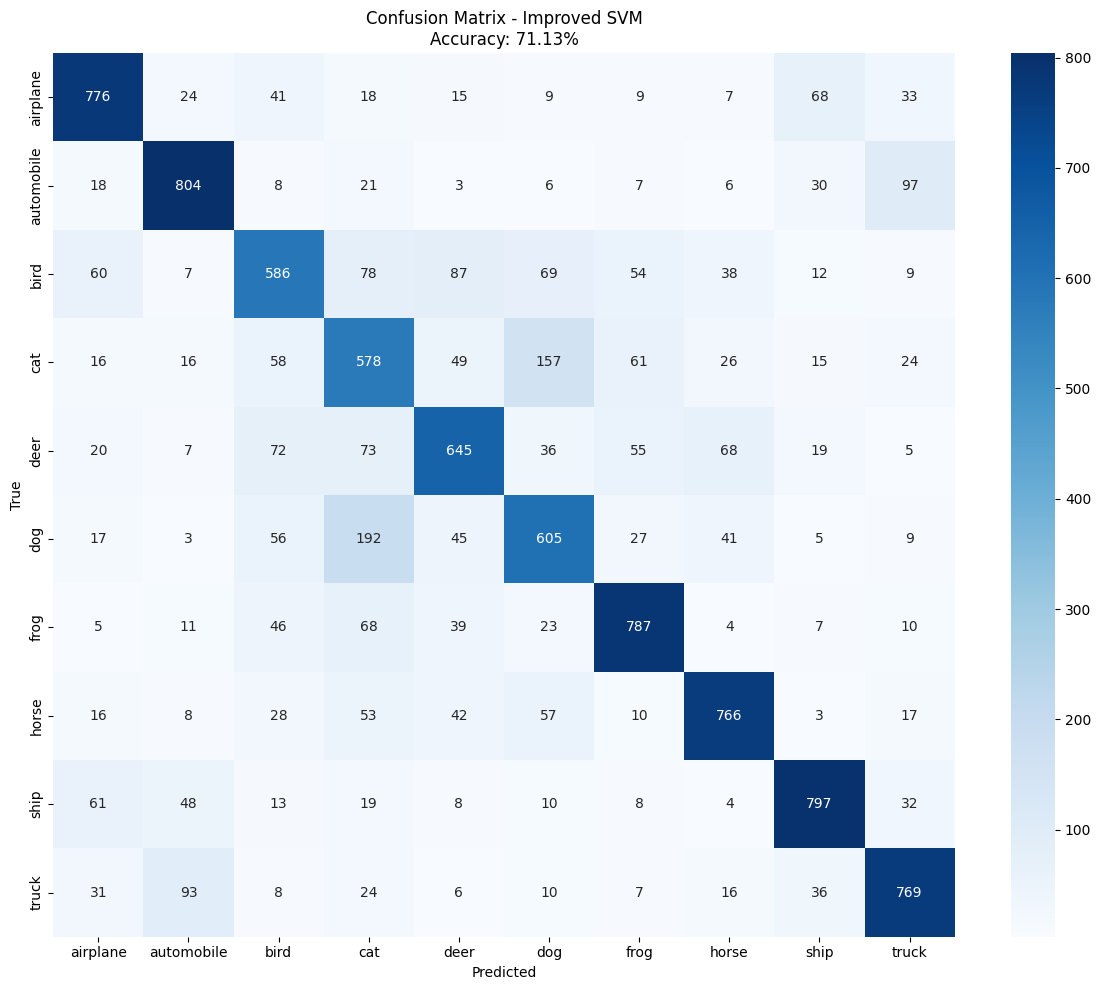

In [22]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("\nClassification Report (IMPROVED):")
print(classification_report(y_test, predictions, target_names=class_names))

print("\nPer-class Accuracy:")
for i, name in enumerate(class_names):
    mask = y_test == i
    class_acc = np.mean(predictions[mask] == y_test[mask])
    print(f"  {name:12s}: {class_acc*100:.2f}%")

# Confusion matrix
import seaborn as sns

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Confusion Matrix - Improved SVM\nAccuracy: {accuracy*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig('phase4_improved_confusion.png', dpi=150)
plt.show()
